In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.concat([X, y], axis=1)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.shape

(48842, 15)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [7]:
df.info

<bound method DataFrame.info of        age         workclass  fnlwgt  education  education-num  \
0       39         State-gov   77516  Bachelors             13   
1       50  Self-emp-not-inc   83311  Bachelors             13   
2       38           Private  215646    HS-grad              9   
3       53           Private  234721       11th              7   
4       28           Private  338409  Bachelors             13   
...    ...               ...     ...        ...            ...   
48837   39           Private  215419  Bachelors             13   
48838   64               NaN  321403    HS-grad              9   
48839   38           Private  374983  Bachelors             13   
48840   44           Private   83891  Bachelors             13   
48841   35      Self-emp-inc  182148  Bachelors             13   

           marital-status         occupation    relationship  \
0           Never-married       Adm-clerical   Not-in-family   
1      Married-civ-spouse    Exec-managerial   

In [8]:
df.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [9]:
df.query("workclass.isnull()").head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32565,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.
32567,29,NaN,227026,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K.
32574,58,NaN,299831,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K.
32583,72,NaN,132015,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K.
32596,65,NaN,191846,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K.


In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [12]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [13]:
df["income"].unique()

array(['<=50K', '>50K', '<=50K.', '>50K.'], dtype=object)

In [14]:
df["income"] = df["income"].map({"<=50K": -1, ">50K": 1, "<=50K.": -1, ">50K.": 1})

C:\Users\abdul\AppData\Local\Temp\ipykernel_39080\1907846109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["income"] = df["income"].map({"<=50K": -1, ">50K": 1, "<=50K.": -1, ">50K.": 1})


In [15]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,-1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,-1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,-1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,-1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,-1
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,-1
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,-1
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,-1


In [16]:
# income_array = df['income'].to_numpy() 
# print("Income array:", income_array)

# df = df.drop(columns=['income'])
# print("\nDataFrame after dropping 'income':\n")
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,-1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,-1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,-1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,-1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,-1


In [17]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
count,47621.000000,4.762100e+04,47621.000000,47621.000000,47621.000000,47621.000000,47621.000000
mean,38.640684,1.897271e+05,10.090821,1091.137649,87.853489,40.600050,-0.515298
std,13.558961,1.055695e+05,2.568320,7487.228336,404.010612,12.260345,0.857020
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,-1.000000
25%,28.000000,1.175840e+05,9.000000,0.000000,0.000000,40.000000,-1.000000
50%,37.000000,1.782820e+05,10.000000,0.000000,0.000000,40.000000,-1.000000
75%,48.000000,2.377200e+05,12.000000,0.000000,0.000000,45.000000,-1.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [18]:
print(df.shape)
print(df.columns)
print(df.head())
print(df.tail())
df.info()
print(df.describe())

(47621, 15)
Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    M

In [19]:
print(df["age"].describe())
print("=" * 40)
print(df["income"].describe())

count    47621.000000
mean        38.640684
std         13.558961
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64
count    47621.000000
mean        -0.515298
std          0.857020
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max          1.000000
Name: income, dtype: float64


In [20]:
# IQR = Q3 - Q1 formula
Q1 = df["age"].quantile(0.25)
Q2 = df["age"].quantile(0.50)
Q3 = df["age"].quantile(0.75)
print("=" * 40)
IQR = Q3 - Q1

print("Q1 =", Q1)
print("Median =", Q2)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 28.0
Median = 37.0
Q3 = 48.0
IQR = 20.0


In [21]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Lower Bound = -2.0
Upper Bound = 78.0


In [22]:
outliers_age = df[(df["age"] < lower_bound) | (df["age"] > upper_bound)]

print("Number of outliers in Age =", outliers_age.shape[0])
print(outliers_age[["age"]].head(10))

Number of outliers in Age = 200
      age
74     79
222    90
430    80
918    81
1040   90
1168   88
1935   90
2303   90
2754   80
2891   90


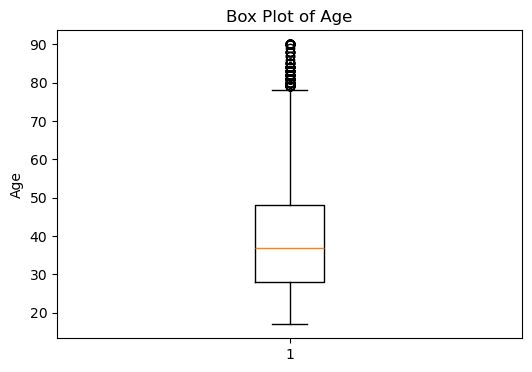

In [23]:
plt.figure(figsize=(6, 4))
plt.boxplot(df["age"].dropna())
plt.title("Box Plot of Age")
plt.ylabel("Age")
plt.show()

In [24]:
# IQR = Q3 - Q1 formula
Q1 = df["income"].quantile(0.25)
Q2 = df["income"].quantile(0.50)
Q3 = df["income"].quantile(0.75)
print("=" * 40)
IQR = Q3 - Q1

print("Q1 =", Q1)
print("Median =", Q2)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = -1.0
Median = -1.0
Q3 = -1.0
IQR = 0.0


In [25]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Lower Bound = -1.0
Upper Bound = -1.0


In [26]:
# print("Lower bound =", lower_bound)
# print("Upper bound =", upper_bound)

In [27]:
outliers_income = df[(df["income"] < lower_bound) | (df["income"] > upper_bound)]

print("Number of outliers in Income =", outliers_income.shape[0])
print(outliers_income[["income"]].head(10))

Number of outliers in Income = 11541
    income
7        1
8        1
9        1
10       1
11       1
14       1
19       1
20       1
25       1
27       1


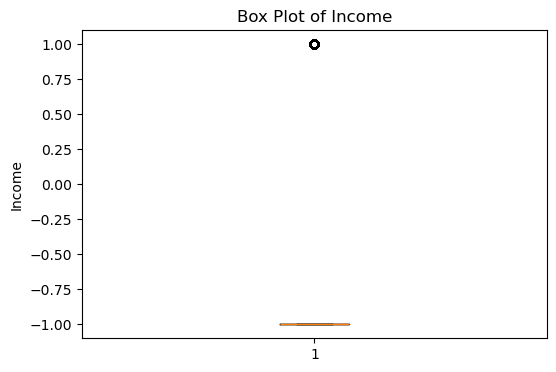

In [28]:
plt.figure(figsize=(6, 4))
plt.boxplot(df["income"].dropna())
plt.title("Box Plot of Income")
plt.ylabel("Income")
plt.show()

In [29]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [30]:
# CapitalGain
Q1_cg = df["capital-gain"].quantile(0.25)
Q2_cg = df["capital-gain"].quantile(0.50)
Q3_cg = df["capital-gain"].quantile(0.75)
IQR_cg = Q3_cg - Q1_cg

In [31]:
print("capital-gain")
print("Q1 =", Q1_cg)
print("Median =", Q2_cg)
print("Q3 =", Q3_cg)
print("IQR =", IQR_cg)

capital-gain
Q1 = 0.0
Median = 0.0
Q3 = 0.0
IQR = 0.0


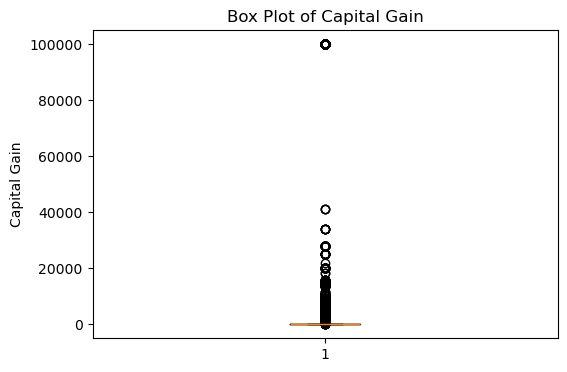

In [32]:
plt.figure(figsize=(6, 4))
plt.boxplot(df["capital-gain"].dropna())
plt.title("Box Plot of Capital Gain")
plt.ylabel("Capital Gain")
plt.show()

In [33]:
Q1_cl = df["capital-loss"].quantile(0.25)
Q2_cl = df["capital-loss"].quantile(0.50)
Q3_cl = df["capital-loss"].quantile(0.75)
IQR_cl = Q3_cl - Q1_cl

In [34]:
print("\nCapitalLoss")
print("Q1 =", Q1_cl)
print("Median =", Q2_cl)
print("Q3 =", Q3_cl)
print("IQR =", IQR_cl)


CapitalLoss
Q1 = 0.0
Median = 0.0
Q3 = 0.0
IQR = 0.0


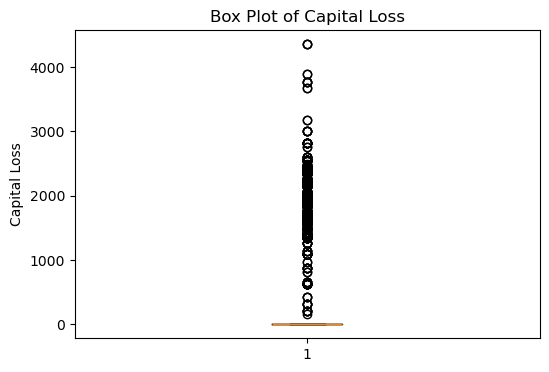

In [35]:
plt.figure(figsize=(6, 4))
plt.boxplot(df["capital-loss"].dropna())
plt.title("Box Plot of Capital Loss")
plt.ylabel("Capital Loss")
plt.show()

In [36]:
print(df["capital-gain"].describe())
print("=" * 40)
print(df["capital-loss"].describe())

count    47621.000000
mean      1091.137649
std       7487.228336
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64
count    47621.000000
mean        87.853489
std        404.010612
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64


In [37]:
# percentage of zero values
capital_gain_zero_pct = (df["capital-gain"] == 0).mean() * 100
capital_loss_zero_pct = (df["capital-loss"] == 0).mean() * 100

print("Percentage of CapitalGain == 0:", round(capital_gain_zero_pct, 2), "%")
print("Percentage of CapitalLoss == 0:", round(capital_loss_zero_pct, 2), "%")

Percentage of CapitalGain == 0: 91.68 %
Percentage of CapitalLoss == 0: 95.31 %


In [38]:
print(df["capital-gain"].value_counts().head(10))
print(df["capital-loss"].value_counts().head(10))

capital-gain
0        43657
15024      508
7688       405
7298       357
99999      240
3103       149
5178       143
5013       116
4386       105
8614        81
Name: count, dtype: int64
capital-loss
0       45389
1902      302
1977      252
1887      232
2415       72
1485       71
1848       66
1590       61
1876       59
1740       58
Name: count, dtype: int64


In [39]:
df = df.drop(columns=["capital-gain", "capital-loss"])
print(df.head())

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   hours-per-week native-country  income  
0              40  United-States      -1  
1              13  United-States      -1  
2              40  United-States      -1  
3         

In [40]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,-1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,-1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,-1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,-1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,40,United-States,-1
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,36,United-States,-1
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,50,United-States,-1
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,40,United-States,-1


['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],


In [41]:
cat_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]

for col in cat_cols:
    print("\n" + "=" * 40)
    print("Column:", col)
    print("Unique values:")
    print(df[col].unique())
    print("Distinct count:", df[col].nunique())


Column: workclass
Unique values:
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
Distinct count: 9

Column: education
Unique values:
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
Distinct count: 16

Column: marital-status
Unique values:
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
Distinct count: 7

Column: occupation
Unique values:
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
Distinct count: 15

Column: relationship
Unique values:
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
Distinct count: 6

Colum

In [42]:
print(df[cat_cols].nunique())

workclass          9
education         16
marital-status     7
occupation        15
relationship       6
race               5
sex                2
native-country    42
dtype: int64


In [43]:
df_encoded = pd.get_dummies(df, columns=cat_cols, dtype=int)

print("Shape after one-hot encoding:", df_encoded.shape)
print(df_encoded.head())

Shape after one-hot encoding: (47621, 107)
   age  fnlwgt  education-num  hours-per-week  income  workclass_?  \
0   39   77516             13              40      -1            0   
1   50   83311             13              13      -1            0   
2   38  215646              9              40      -1            0   
3   53  234721              7              40      -1            0   
4   28  338409             13              40      -1            0   

   workclass_Federal-gov  workclass_Local-gov  workclass_Never-worked  \
0                      0                    0                       0   
1                      0                    0                       0   
2                      0                    0                       0   
3                      0                    0                       0   
4                      0                    0                       0   

   workclass_Private  ...  native-country_Portugal  \
0                  0  ...                  

In [44]:
print(df_encoded.columns)

Index(['age', 'fnlwgt', 'education-num', 'hours-per-week', 'income',
       'workclass_?', 'workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private',
       ...
       'native-country_Portugal', 'native-country_Puerto-Rico',
       'native-country_Scotland', 'native-country_South',
       'native-country_Taiwan', 'native-country_Thailand',
       'native-country_Trinadad&Tobago', 'native-country_United-States',
       'native-country_Vietnam', 'native-country_Yugoslavia'],
      dtype='object', length=107)


In [45]:
df_encoded.head()

,age,fnlwgt,education-num,hours-per-week,income,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,40,-1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,83311,13,13,-1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,215646,9,40,-1,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,53,234721,7,40,-1,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28,338409,13,40,-1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [46]:
male_df = df[df["sex"] == "Male"]
female_df = df[df["sex"] == "Female"]

male_gt50k_df = df[(df["sex"] == "Male") & (df["income"] == ">50K")]
female_gt50k_df = df[(df["sex"] == "Female") & (df["income"] == ">50K")]
female_lt50k_df = df[(df["sex"] == "Female") & (df["income"] == "<=50K")]

male_count = male_df.shape[0]
female_count = female_df.shape[0]

male_gt50k = male_gt50k_df.shape[0]
female_gt50k = female_gt50k_df.shape[0]

avg_age_male_gt50k = male_gt50k_df["age"].mean()
avg_age_female_lt50k = female_lt50k_df["age"].mean()

std_male = male_df["age"].std()
std_female = female_df["age"].std()

skew_male = male_df["age"].skew()
skew_female = female_df["age"].skew()

mean_diff_age = male_df["age"].mean() - female_df["age"].mean()

print("Count of total male from data =", male_count)
print("Count of total female from data =", female_count)
print("Count of total male whose salary >50K =", male_gt50k)
print("Count of total female whose salary >50K =", female_gt50k)
print("Average age of male whose salary >50K =", round(avg_age_male_gt50k, 2))
print("Average age of female whose salary <50K =", round(avg_age_female_lt50k, 2))
print("Standard deviation of male age =", round(std_male, 2))
print("Standard deviation of female age =", round(std_female, 2))
print("Skewness of male population =", round(skew_male, 2))
print("Skewness of female population =", round(skew_female, 2))
print("Mean difference of male and female age =", round(mean_diff_age, 2))

Count of total male from data = 31937
Count of total female from data = 15684
Count of total male whose salary >50K = 0
Count of total female whose salary >50K = 0
Average age of male whose salary >50K = nan
Average age of female whose salary <50K = nan
Standard deviation of male age = 13.25
Standard deviation of female age = 14.02
Skewness of male population = 0.52
Skewness of female population = 0.67
Mean difference of male and female age = 2.5


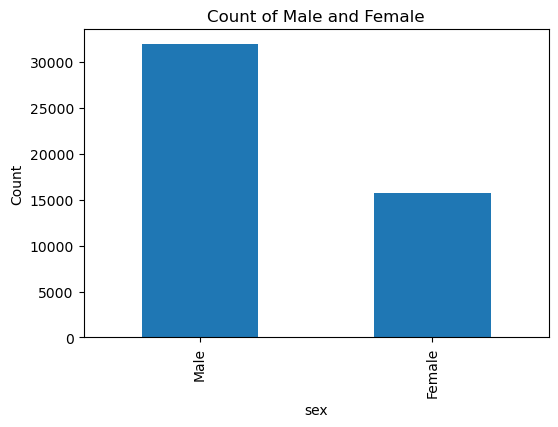

In [47]:
plt.figure(figsize=(6, 4))
df["sex"].value_counts().plot(kind="bar")
plt.title("Count of Male and Female")
plt.xlabel("sex")
plt.ylabel("Count")
plt.show()

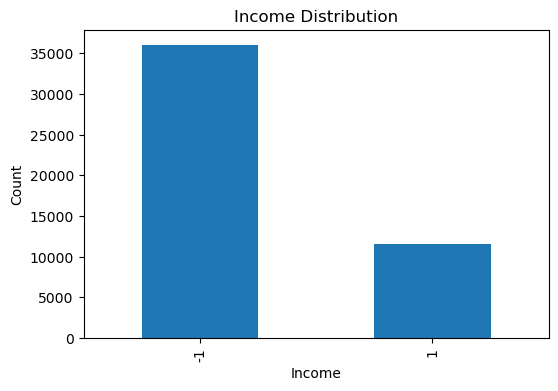

In [48]:
plt.figure(figsize=(6, 4))
df["income"].value_counts().plot(kind="bar")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

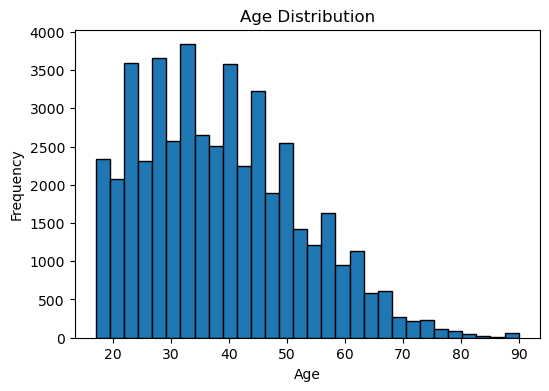

In [49]:
plt.figure(figsize=(6, 4))
plt.hist(df["age"], bins=30, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [50]:
df["hours-per-week"]

0        40
1        13
2        40
3        40
4        40
         ..
48836    40
48837    36
48839    50
48840    40
48841    60
Name: hours-per-week, Length: 47621, dtype: int64

In [51]:
# plt.figure(figsize=(8, 6))
# plt.scatter(
#     male_gt50k_df["age"], male_gt50k_df["hours-per-week"], alpha=0.4, label="Male >50K"
# )
# plt.scatter(
#     female_gt50k_df["age"],
#     female_gt50k_df["hours-per-week"],
#     alpha=0.4,
#     label="Female >50K",
# )

# plt.title("Age vs HoursPerWeek for Income >50K")
# plt.xlabel("Age")
# plt.ylabel("HoursPerWeek")
# plt.legend()
# plt.show()